## Step 1: Load the Data and Split them

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the data

data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/headlines_clean.csv")

# Get only the parts we need from the csv (we don't need source and source_type)
data = data[["headline", "label"]]

# Check the class distribution
print(data["label"].value_counts())

# Split the data into training and testing sets
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42, stratify=data["label"])

print("Training data lenght:", len(train_data))
print("Testing data lenght:", len(test_data))


label
0    269
1    178
Name: count, dtype: int64
Training data lenght: 357
Testing data lenght: 90


In [5]:
## Tokenization
import sys
from transformers import AutoTokenizer
from datasets import Dataset

# Fix for 'VideoReader' ImportError in Colab
sys.modules['torchvision'] = None

# Load SlovakBERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("gerulata/slovakbert")

# Convert from Pandas into Huggingface datasets
train_dataset = Dataset.from_pandas(train_data.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_data.reset_index(drop=True))

# Create the function that will turn text into vectors
def tokenize(input):
  return tokenizer(
    input["headline"],
    padding="max_length", # We always make all the parts the same lenght for efficient proccessing and storing
    truncation=True, # Cut of anything after the max allowed lenght
    max_length=64
  )

# Apply tokenizer to both sets, add as new rows so we keep the original headling if needed
train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

# Tell HuggingFace which colums the model needs
train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# Restore torchvision after formatting is done
del sys.modules['torchvision']

print("Example:", train_dataset[0]['input_ids'])
print("Example:", train_dataset[0]['attention_mask'])
print("Example:", train_dataset[0]['label'])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/581 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.13M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/533k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Map:   0%|          | 0/357 [00:00<?, ? examples/s]

Map:   0%|          | 0/90 [00:00<?, ? examples/s]

Example: tensor([    0, 25708, 25588,     8,   383, 12832, 49057,  3796, 50244,   529,
        19086,     8, 17801,    31, 10038,  8840, 25151,     2,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1])
Example: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
Example: tensor(0)


## Step 2: Load and Train SlovakBERT

In [6]:
from transformers import AutoModelForSequenceClassification


# Load the model
model = AutoModelForSequenceClassification.from_pretrained("gerulata/slovakbert", num_labels=2) # Two labels: legit "0" and clickbait "1"




model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: gerulata/slovakbert
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.decoder.bias       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [7]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight


# Since I have 178 clickbait classified titles and 269 legit, we make missclasifying the minority more expensive
# Therefore not bias the model towards it
class_weights = compute_class_weight(
    "balanced",
    classes=np.array([0, 1]), # Make the whole array with the 0 and 1
    y=train_data["label"] # Get the 0 and 1 from the train dataset and have the class computer the weights
)

print(f"Class weights: legit={class_weights[0]:.3f}, clickbait={class_weights[1]:.3f}")
# Clickbait weight will be higher because there are fewer of them

Class weights: legit=0.830, clickbait=1.257


In [8]:
import torch
from transformers import Trainer, TrainingArguments

# Convert weights to a PyTorch tensor and move to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels") # Extract tru target answer (0 or 1)
        outputs = model(**inputs) # Pass remaining text tokens and masks into tranformer
        logits = outputs.logits  # Raw scores before probability conversion (logits)

        # Pass the new weighted Cross-Entropy Loss
        loss_function = torch.nn.CrossEntropyLoss(weight=weights_tensor)
        loss = loss_function(logits, labels)

        # Return the correct thing when we both train and evalueate
        return (loss, outputs) if return_outputs else loss

In [9]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=5,            # how many times to go through the full dataset
    per_device_train_batch_size=16, # process 16 headlines at once (GPU memory limit)
    per_device_eval_batch_size=32,  # can use larger batch for eval
    learning_rate=2e-5,             # how big the adjustment steps are
    weight_decay=0.01,              # regularization - prevents overfitting
    eval_strategy="epoch",          # evaluate on test set after each epoch
    save_strategy="epoch",
    load_best_model_at_end=True,    # keep the version that performed best on test set
    metric_for_best_model="f1",     # use F1 to pick the best model (not accuracy, because of imbalance)
    logging_steps=10,               # print loss every 10 steps
)

In [10]:
from sklearn.metrics import accuracy_score, f1_score
# The "Report Card"
# Runs after each epoch(1 whole dataset passthorugh) on the test set
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)  # pick whichever decision has the higher score
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions),  # defaults to binary F1 for the positive class (clickbait)
    }

In [13]:
import sys
# Ensure torchvision is fully removed from sys.modules to avoid the VideoReader ImportError
if 'torchvision' in sys.modules:
    del sys.modules['torchvision']

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,    # your tokenized training data from Step 2
    eval_dataset=test_dataset,      # your tokenized test data from Step 2
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.191647,0.393913,0.866667,0.833333
2,0.096874,0.531655,0.877778,0.840580
3,0.160941,0.499599,0.877778,0.849315
4,0.115890,0.511920,0.888889,0.864865
5,0.068497,0.501249,0.877778,0.849315


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=115, training_loss=0.16010647908501002, metrics={'train_runtime': 38.4021, 'train_samples_per_second': 46.482, 'train_steps_per_second': 2.995, 'total_flos': 58706654227200.0, 'train_loss': 0.16010647908501002, 'epoch': 5.0})

              precision    recall  f1-score   support

       legit       0.92      0.89      0.91        54
   clickbait       0.84      0.89      0.86        36

    accuracy                           0.89        90
   macro avg       0.88      0.89      0.89        90
weighted avg       0.89      0.89      0.89        90



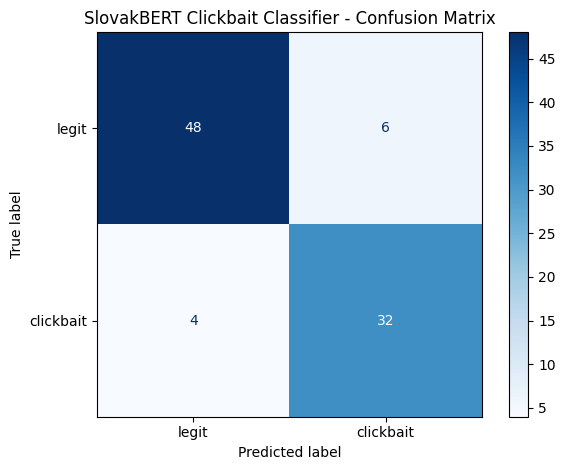

In [14]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get predictions from the best model
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)  # convert logits to class predictions
true_labels = predictions.label_ids

# Print the classification report (precision, recall, F1 per class)
print(classification_report(true_labels, preds, target_names=["legit", "clickbait"]))

# Plot confusion matrix
cm = confusion_matrix(true_labels, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["legit", "clickbait"])
disp.plot(cmap="Blues")
plt.title("SlovakBERT Clickbait Classifier - Confusion Matrix")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/confusion_matrix.png", dpi=150)
plt.show()

In [15]:
print("WRONG PREDICTIONS")
print("=================")
print()

wrong_count = 0

for i in range(len(preds)):
    if preds[i] != true_labels[i]:
        wrong_count = wrong_count + 1

        if true_labels[i] == 1:
            actual = "clickbait"
        else:
            actual = "legit"

        if preds[i] == 1:
            predicted = "clickbait"
        else:
            predicted = "legit"

        headline = test_data.iloc[i]["headline"]
        print("Headline:", headline)
        print("  True:", actual, "| Predicted:", predicted)
        print()

print("Total wrong:", wrong_count, "out of", len(preds))

WRONG PREDICTIONS

Headline: Premiér Fico objavil v zákone nečakanú kľučku: Tento ťah mení všetko, no experti len krútia hlavou
  True: legit | Predicted: clickbait

Headline: Ostrá kritika od Hargaša: Výstavba D1 Turany - Hubová sa posúva pre neschopnosť Ráža
  True: clickbait | Predicted: legit

Headline: Definitívne rozhodnutie: Minister Šutaj Eštok musí zaplatiť čurillovcom 6-cifernú sumu
  True: legit | Predicted: clickbait

Headline: Ryžové rolky so zeleninou: Jednoduchá ázijská večera s ryžovými rezancami a čili omáčkou
  True: legit | Predicted: clickbait

Headline: Pozlátené sochy aj nápisy: Trump si nechá postaviť víťazný oblúk
  True: clickbait | Predicted: legit

Headline: Saksun prežil vďaka jedinej žene, dnes patrí medzi najkrajšie dediny sveta
  True: clickbait | Predicted: legit

Headline: Nočný požiar odpadu v bratislavskej Petržalke: Príčina je zatiaľ neznáma
  True: legit | Predicted: clickbait

Headline: Premiér Fico sa v Bratislave stretol so srbským ministrom obra

In [16]:
def classify_headline(headline):
    # Tokenize the input headline the same way we did for training
    inputs = tokenizer(
        headline,
        padding="max_length",
        truncation=True,
        max_length=64,
        return_tensors="pt"  # return pytorch tensors
    )

    # Move to GPU
    inputs = {key: value.to(device) for key, value in inputs.items()}

    # Tell PyTorch we're not training, just predicting
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    # Convert logits to probabilities using softmax
    probabilities = torch.softmax(outputs.logits, dim=1)

    # Get the predicted class and its confidence
    predicted_class = torch.argmax(probabilities).item()
    confidence = probabilities[0][predicted_class].item()

    label = "CLICKBAIT" if predicted_class == 1 else "LEGIT"
    print("Headline:", headline)
    print("Prediction:", label)
    print("Confidence:", str(round(confidence * 100, 1)) + "%")

In [ ]:
classify_headline("Slovensko zasiahli silné búrky, bez elektriny je 10 000 domácností")

In [ ]:
classify_headline("Neuveríte, čo táto žena našla vo svojom záhrade! Video vás šokuje")


In [ ]:
classify_headline("Fico oznámil nové opatrenia proti inflácii")


In [ ]:
classify_headline("Fico oznámil nové opatrenia proti inflácii: Tento krok zmení životy tisícov Slovákov")

In [17]:
trainer.save_model("./best_model")
tokenizer.save_pretrained("./best_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./best_model/tokenizer_config.json', './best_model/tokenizer.json')

In [18]:
import shutil
shutil.make_archive("best_model", "zip", ".", "best_model")

'/content/best_model.zip'